# CivicReport AI — Training SVM + TF-IDF

Notebook versi rapi untuk melatih model SVM klasifikasi keluhan masyarakat.

Kategori:
- Infrastruktur
- Kebersihan
- Banjir
- Keamanan
- Administrasi

Urutan notebook dibuat agar training selesai terlebih dahulu sebelum evaluasi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Library berhasil di-import.")


Library berhasil di-import.


## 1. Load Dataset


In [2]:
DATA_FILE = "data_keluhan_masyarakat.csv"

df = pd.read_csv(DATA_FILE)

print("Jumlah data:", len(df))
print("Kolom:", list(df.columns))

display(df.head(10))


Jumlah data: 1000
Kolom: ['text', 'label']


,text,label
0,Antrian layanan KK di kantor kecamatan terlalu...,Administrasi
1,Antrian layanan KTP di loket pelayanan tertund...,Administrasi
2,"Area dekat pasar rawan begal, terutama malam h...",Keamanan
3,Pengurusan akta kelahiran di kelurahan tidak j...,Administrasi
4,Banjir terjadi di sekitar puskesmas akibat gor...,Banjir
5,"Area jalan utama rawan pencurian, terutama akh...",Keamanan
6,jalan di gang kecil berlubang dan menyebabkan ...,Infrastruktur
7,Pengangkutan sampah di RW 05 meluap sehingga m...,Kebersihan
8,Warga melaporkan vandalisme di area parkir yan...,Keamanan
9,"Mohon penanganan banjir di komplek perumahan, ...",Banjir


## 2. Cek Dataset


In [3]:
print("Distribusi kategori:")
print(df["label"].value_counts())

print("\nJumlah data kosong:")
print(df.isnull().sum())


Distribusi kategori:
label
Administrasi     200
Keamanan         200
Banjir           200
Infrastruktur    200
Kebersihan       200
Name: count, dtype: int64

Jumlah data kosong:
text     0
label    0
dtype: int64


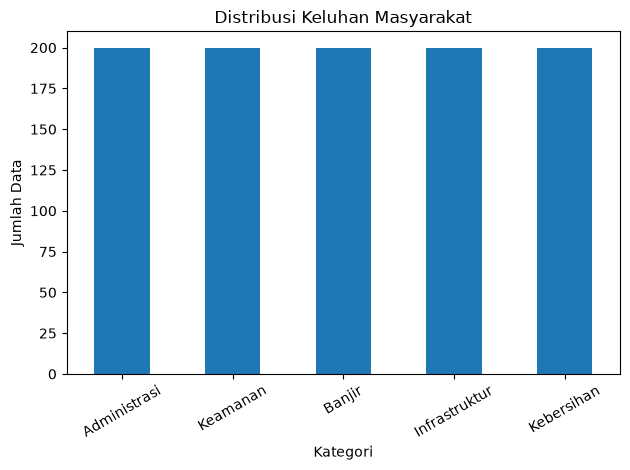

In [4]:
df["label"].value_counts().plot(kind="bar")
plt.title("Distribusi Keluhan Masyarakat")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3. Train-Test Split

Data dibagi menjadi:
- 80% data training
- 20% data testing

`stratify=y` digunakan agar proporsi setiap kategori tetap seimbang.


In [5]:
X = df["text"].astype(str)
y = df["label"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))


Data training: 800
Data testing : 200


## 4. TF-IDF Vectorization


In [6]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape training:", X_train_tfidf.shape)
print("Shape testing :", X_test_tfidf.shape)
print("Jumlah fitur :", len(vectorizer.get_feature_names_out()))


Shape training: (800, 866)
Shape testing : (200, 866)
Jumlah fitur : 866


## 5. Training Model SVM

**Bagian penting:** model dibuat dan dilatih terlebih dahulu sebelum digunakan untuk prediksi.


In [7]:
model = SVC(
    kernel="linear",
    C=1.0
)

model.fit(X_train_tfidf, y_train)

print("Training SVM selesai.")
print("Kategori yang dipelajari:")
print(model.classes_)


Training SVM selesai.
Kategori yang dipelajari:
['Administrasi' 'Banjir' 'Infrastruktur' 'Keamanan' 'Kebersihan']


## 6. Prediksi Data Testing


In [8]:
y_pred = model.predict(X_test_tfidf)

print("Prediksi selesai.")
print("Jumlah prediksi:", len(y_pred))


Prediksi selesai.
Jumlah prediksi: 200


## 7. Evaluasi Model — Accuracy


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("HASIL EVALUASI MODEL SVM")
print("=" * 50)
print(f"Akurasi       : {accuracy:.4f}")
print(f"Akurasi (%)   : {accuracy * 100:.2f}%")


HASIL EVALUASI MODEL SVM
Akurasi       : 1.0000
Akurasi (%)   : 100.00%


## 8. Classification Report


In [10]:
print(classification_report(
    y_test,
    y_pred,
    digits=4
))


               precision    recall  f1-score   support

 Administrasi     1.0000    1.0000    1.0000        40
       Banjir     1.0000    1.0000    1.0000        40
Infrastruktur     1.0000    1.0000    1.0000        40
     Keamanan     1.0000    1.0000    1.0000        40
   Kebersihan     1.0000    1.0000    1.0000        40

     accuracy                         1.0000       200
    macro avg     1.0000    1.0000    1.0000       200
 weighted avg     1.0000    1.0000    1.0000       200



## 9. Confusion Matrix


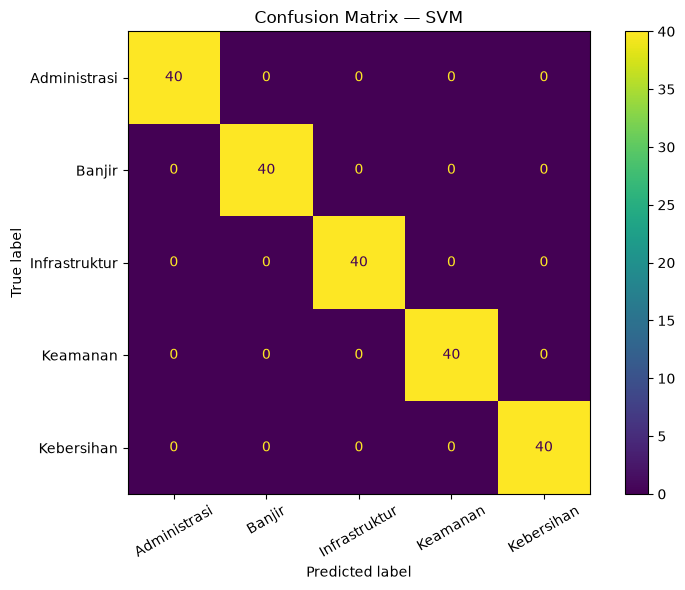

In [11]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=30
)

plt.title("Confusion Matrix — SVM")
plt.tight_layout()
plt.show()


## 10. Uji Keluhan Baru

Bagian ini digunakan untuk memastikan model dapat digunakan untuk menerima keluhan baru.


In [12]:
contoh_keluhan = [
    "Jalan depan sekolah berlubang dan membahayakan pengendara.",
    "Sampah menumpuk di dekat pasar dan menimbulkan bau.",
    "Hujan deras menyebabkan jalan tergenang setinggi 30 cm.",
    "Sering terjadi pencurian di area parkir pada malam hari.",
    "Pengurusan KTP di kantor kecamatan sangat lama."
]

X_contoh = vectorizer.transform(contoh_keluhan)
hasil_prediksi = model.predict(X_contoh)

for teks, kategori in zip(contoh_keluhan, hasil_prediksi):
    print("Keluhan :", teks)
    print("Kategori:", kategori)
    print("-" * 80)


Keluhan : Jalan depan sekolah berlubang dan membahayakan pengendara.
Kategori: Infrastruktur
--------------------------------------------------------------------------------
Keluhan : Sampah menumpuk di dekat pasar dan menimbulkan bau.
Kategori: Kebersihan
--------------------------------------------------------------------------------
Keluhan : Hujan deras menyebabkan jalan tergenang setinggi 30 cm.
Kategori: Banjir
--------------------------------------------------------------------------------
Keluhan : Sering terjadi pencurian di area parkir pada malam hari.
Kategori: Keamanan
--------------------------------------------------------------------------------
Keluhan : Pengurusan KTP di kantor kecamatan sangat lama.
Kategori: Administrasi
--------------------------------------------------------------------------------


## 11. Simpan Model

Dua file berikut akan digunakan oleh FastAPI:
- `model.pkl` → model SVM
- `vectorizer.pkl` → TF-IDF Vectorizer


In [13]:
joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Berhasil menyimpan:")
print("✓ model.pkl")
print("✓ vectorizer.pkl")


Berhasil menyimpan:
✓ model.pkl
✓ vectorizer.pkl


## 12. Verifikasi File

Pastikan kedua file benar-benar dapat dibaca kembali.


In [14]:
model_check = joblib.load("model.pkl")
vectorizer_check = joblib.load("vectorizer.pkl")

print("Model berhasil dibaca:", model_check)
print("Vectorizer berhasil dibaca:", vectorizer_check)
print("Kategori model:", model_check.classes_)


Model berhasil dibaca: SVC(kernel='linear')
Vectorizer berhasil dibaca: TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
Kategori model: ['Administrasi' 'Banjir' 'Infrastruktur' 'Keamanan' 'Kebersihan']


## Selesai

Jika semua cell berhasil dijalankan tanpa error, project sudah memiliki:

```text
model.pkl
vectorizer.pkl
```

Keduanya siap digunakan oleh `api.py`.
